In [1]:
import pandas as pd
import numpy as np

pandas作为数据分析的基础库，提供了非常丰富的数据文件读取方法，可以对csv, Excel, json, sql, html, spss ,sas, stata等多种格式的数据进行读取和写入。

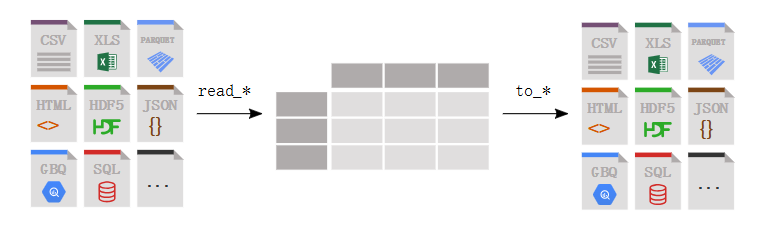

# 1.可读写数据

## 1.1读写本地文件
本地文件就是本地存储的文件，可以用一个链接或者一个映射来表示。  
可以用以下3种方式来导入本地文件  

In [2]:
path1='c:\\users\\administrator\\desktop\\student.csv'  #使用双反斜杠\\进行显式转义  
path2='c:/users/administrator/desktop/student.csv'  #Python内部会自动转换为当前系统的路径分隔符
path3=r'c:\users\administrator\desktop\student.csv'  #前缀r使字符串内字符保持原样，\` 不再具有转义功能

In [3]:
# 当前目录文件
current_file = "data.csv"  # 直接文件名（当前目录）或者使用./开头
# 上层目录文件
parent_file = "../parent_data.csv"  # 相对路径
# 上上层目录文件
grandparent_file = "../../grandparent_data.xlsx"
# 下层目录文件
child_file = "subfolder/child_data.json"

| 模式 | 描述             | 文件存在 | 文件不存在 | 指针位置          | 典型用途                   |
| ---- | ---------------- | -------- | ---------- | ----------------- | :------------------------- |
| 'r'  | 只读模式（默认） | 打开文件 | 抛出错误   | 文件开头          | 读取文本文件               |
| 'rb' | 二进制只读       | 打开文件 | 抛出错误   | 文件开头          | 读取图片、视频等二进制文件 |
| 'r+' | 读写模式         | 打开文件 | 抛出错误   | 文件开头          | 需要同时读写文件           |
| 'w'  | 只写模式         | 清空文件 | 创建新文件 | 文件开头          | 覆盖写入新内容             |
| 'wb' | 二进制只写       | 清空文件 | 创建新文件 | 文件开头          | 写入二进制数据             |
| 'w+' | 读写模式         | 清空文件 | 创建新文件 | 文件开头          | 读写文件（先清空）         |
| 'a'  | 追加模式         | 打开文件 | 创建新文件 | 文件末尾          | 日志记录                   |
| 'ab' | 二进制追加       | 打开文件 | 创建新文件 | 文件末尾          | 追加二进制数据             |
| 'a+' | 读写追加         | 打开文件 | 创建新文件 | 读取开头/写入末尾 | 需要追加和读取             |

## 1.2 I/0 API工具

Pandas是数据分析的重要工具，其最重要的功能就是数据计算和处理。从外部获取数据也是数据处理的一部分。读写数据对于数据分析非常重要。Pandas有专门的数据处理工具库，提供一组I/O API函数。这些函数可以分为两大类。读取函数和写入函数。

| 读取函数   | 写入函数 | 读取函数       | 写入函数     |
| ---------- | -------- | -------------- | ------------ |
| read_csv   | to_csv   | read_xml       | to_xml       |
| read_excel | to_excel | read_stata     | to_stata     |
| read_json  | to_json  | read_clipboard | to_clipboard |
| read_html  | to_html  | read_pickle    | to_pickle    |
| read_sql   | to_sql   | read_msgpack   | to_msgpack   |
| read_hdf   | to_hdf   | read_gbq       | to_gbq       |

读取函数一般会赋值给一个变量 df, df = pd.read_<xxx>()  
输出函数是将变量自身进行操作并输出 df.to_<xxx>()

# 2. CSV文件的读写

## 2.1 CSV文件的读取

（1）CSV是Comma Separated Values的简称，是指用逗号（，）分隔的**文本文件**。CSV文件**不支持多个“工作表”**。<BR>
（2）CSV文件的读取采用**pd.read_csv()**函数，该函数提供了50个参数（?pd.read_csv），可以非常灵活的读取数据。  
（3）**pd.read_csv()**函数须重点掌握的参数：

| 参数                 | 类型             | 默认值 | 描述               | 使用频率 |
| -------------------- | ---------------- | ------ | ------------------ | -------- |
| `filepath_or_buffer` | str/path         | 必填   | 文件路径或文件对象 | ★★★★★    |
| `sep`                | str              | ','    | 字段分隔符         | ★★★★★    |
| `header`             | int/list         | 0      | 表头行位置         | ★★★★★    |
| `names`              | list             | None   | 自定义列名         | ★★★★☆    |
| `index_col`          | int/str          | None   | 指定索引列         | ★★★★☆    |
| `usecols`            | list             | None   | 选择读取的列       | ★★★★☆    |
| `dtype`              | dict             | None   | 列数据类型         | ★★★★☆    |
| `encoding`           | str              | None   | 文件编码           | ★★★★☆    |
| `skiprows`           | list             | None   | 跳过的行           | ★★★☆☆    |

**ParserWarning：**有时候，CSV文件最后一行可能存在由字符串构成的注释信息；另外，pandas解析器使用C语言和Python语言实现的，有时候会存在无法用C语言解析的情况，需要显式指定解析语言为Python。因此，可以在参数中添加参数：skipfooter = 1（或n），engine = 'python'。

In [2]:
# 读取数据源中股票相关数据中data中2023年一季度A股日线行情csv文件, 相对路径
df = pd.read_csv(r'数据源/股票相关数据/data/csv格式/2023年一季度A股日线行情.csv')
df.head(2)

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,000981.SZ,20230103,1.83,1.85,1.80,1.84,1.85,-0.01,-0.5405,494648.83,90550.232
1,000982.SZ,20230103,1.78,1.83,1.77,1.82,1.78,0.04,2.2472,321688.19,58109.761


###  2.1.1基本参数
1、filepath：数据输入的路径：可以是文件路径、可以是URL，也可以是实现read方法的任意对象。这个参数，就是我们输入的第一个参数,可以不写参数名

In [6]:
# 读取数据源中fj_order_data文件
pd.read_csv(r'数据源/fj_order_data.csv')

,order_id,item_name,quantity,item_price
0,1,Chips and Fresh Tomato Salsa,1,$2.39
1,1,Izze,1,$3.39
2,1,Nantucket Nectar,1,$3.39
3,1,Chips and Tomatillo-Green Chili Salsa,1,$2.39
4,2,Chicken Bowl,2,$16.98
...,...,...,...,...
4617,1833,Steak Burrito,1,$11.75
4618,1833,Steak Burrito,1,$11.75
4619,1834,Chicken Salad Bowl,1,$11.25
4620,1834,Chicken Salad Bowl,1,$8.75


In [3]:
# 使用URL：https://www.gairuo.com/file/data/dataset/GDP-China.csv
result = pd.read_csv('https://www.gairuo.com/file/data/dataset/GDP-China.csv')
result.head(2)

,年份,国民总收入,国内生产总值,第一产业增加值,第二产业增加值,第三产业增加值,人均国内生产总值
0,2018,896915.6,900309.5,64734.0,366000.9,469574.6,64644
1,2017,820099.5,820754.3,62099.5,332742.7,425912.1,59201


2、sep：读取csv文件时指定的分隔符，默认为逗号。注意："csv文件的分隔符" 和 "我们读取csv文件时指定的分隔符" 一定要一致。

In [4]:
# 读取数据源中students_step文件
pd.read_csv('数据源/students_step.csv')

,id|name|address|gender|birthday
0,1|朱梦雪|地球村|女|2004/11/2
1,2|许文博|月亮星|女|2003/8/7
2,3|张兆媛|艾尔星|女|2004/11/2
3,4|付延旭|克哈星|男|2003/10/11
4,5|王杰|查尔星|男|2002/6/12
5,6|董泽宇|塔桑尼斯|男|2002/2/12


由于指定的分隔符 和 csv文件采用的分隔符 不一致，因此多个列之间没有分开，而是连在一起了。 所以，我们需要将分隔符设置成"|"才可以。

In [5]:
pd.read_csv('数据源/students_step.csv',sep = '|')

,id,name,address,gender,birthday
0,1,朱梦雪,地球村,女,2004/11/2
1,2,许文博,月亮星,女,2003/8/7
2,3,张兆媛,艾尔星,女,2004/11/2
3,4,付延旭,克哈星,男,2003/10/11
4,5,王杰,查尔星,男,2002/6/12
5,6,董泽宇,塔桑尼斯,男,2002/2/12


3、header和name
- 1.header和 names参数都用于处理列名（表头）
- 2.header参数
  - 作用：指定数据中哪一行（或哪些行）作为列名（表头）。
  - 默认值：header=0（第一行作为列名）。
  - 常见取值：  
    header=0：第一行作为列名（默认）。  
    header=None：数据中无列名，需手动指定或生成默认列名。  
    header=2：第三行作为列名（索引从 0 开始）。  
    header=[0, 1]：前两行组合成多级列名（MultiIndex）。
- 3.names参数
  - 作用：覆盖列名，提供自定义列名列表。
  - 如果文件有表头，names会替换原始表头。
  - 如果文件无表头，names会添加新表头。
  - 格式：names=["列1", "列2", ...]


(1) names 没有被赋值，header 也没赋值：

In [7]:
# 读取数据源中students文件
# 这种情况下，header为0，即选取文件的第一行作为表头
pd.read_csv(r'数据源\students.csv')

,id,name,address,gender,birthday
0,1,朱梦雪,地球村,女,2004/11/2
1,2,许文博,月亮星,女,2003/8/7
2,3,张兆媛,艾尔星,女,2004/11/2
3,4,付延旭,克哈星,男,2003/10/11
4,5,王杰,查尔星,男,2002/6/12
5,6,董泽宇,塔桑尼斯,男,2002/2/12


(2) names 没有被赋值，header 被赋值：

In [8]:
# 读取数据源中students文件
# 不指定names，指定header为1，则选取第二行当做表头，第二行下面为数据
pd.read_csv(r'数据源\students.csv',header = 1)

,1,朱梦雪,地球村,女,2004/11/2
0,2,许文博,月亮星,女,2003/8/7
1,3,张兆媛,艾尔星,女,2004/11/2
2,4,付延旭,克哈星,男,2003/10/11
3,5,王杰,查尔星,男,2002/6/12
4,6,董泽宇,塔桑尼斯,男,2002/2/12


(3) names 被赋值，header 没有被赋值：

In [11]:
# 读取数据源中students文件
# 自定义name
pd.read_csv(r'数据源\students.csv',names = ['编号','姓名','地址','性别','出生日期'])

,编号,姓名,地址,性别,出生日期
0,id,name,address,gender,birthday
1,1,朱梦雪,地球村,女,2004/11/2
2,2,许文博,月亮星,女,2003/8/7
3,3,张兆媛,艾尔星,女,2004/11/2
4,4,付延旭,克哈星,男,2003/10/11
5,5,王杰,查尔星,男,2002/6/12
6,6,董泽宇,塔桑尼斯,男,2002/2/12


可以看到，names适用于没有表头的情况，指定names没有指定header，那么header相当于None。 一般来说，读取文件的时候会有一个表头，一般默认是第一行，但是有的文件中是没有表头的，那么这个时候就可以通过names手动指定、或者生成表头，而文件里面的数据则全部是内容。所以这里id、name、address、date也当成是一条记录了，本来它是表头的，但是我们指定了names，所以它就变成数据了，表头是我们在names里面指定的。 

(4) names和header都被赋值：

In [14]:
# 读取数据源中students文件
pd.read_csv('数据源/students.csv',header = 0,names = ['编号','姓名','地址','性别','出生日期'])

,编号,姓名,地址,性别,出生日期
0,1,朱梦雪,地球村,女,2004/11/2
1,2,许文博,月亮星,女,2003/8/7
2,3,张兆媛,艾尔星,女,2004/11/2
3,4,付延旭,克哈星,男,2003/10/11
4,5,王杰,查尔星,男,2002/6/12
5,6,董泽宇,塔桑尼斯,男,2002/2/12


 这个时候，相当于先不看names，只看header，header为0代表先把第一行当做表头，下面的当成数据；然后再把表头用names给替换掉。

所以names和header的使用场景主要如下：

    ①. csv文件有表头并且是第一行，那么names和header都无需指定;
    ②. csv文件有表头、但表头不是第一行，可能从下面几行开始才是真正的表头和数据，这个时候指定header即可;
    ③. csv文件没有表头，全部是纯数据，那么我们可以通过names手动生成表头;
    ④. csv文件有表头、但是这个表头你不想用，这个时候同时指定names和header。先用header选出表头和数据，然后再用names将表头替换掉，就等价于将数据读取进来之后再对列名进行rename；

4、index_col：我们在读取文件之后所得到的DataFrame的索引默认是0、1、2……，我们可以通过set_index设定索引，但是也可以在读取的时候就指定某列为索引。

In [18]:
# 读取数据源中students文件，将birthday设为索引
df = pd.read_csv('数据源/students.csv',index_col = 'birthday')

In [19]:
# 查看df的行索引
df.index

Index(['2004/11/2', '2003/8/7', '2004/11/2', '2003/10/11', '2002/6/12',
       '2002/2/12'],
      dtype='object', name='birthday')

这里，我们在读取的时候指定了birthday列作为索引； 此外，除了指定单个列，还可以指定多列作为索引，比如["id", "name"]。同时，我们除了可以输入列名外，还可以输入列对应的索引。比如："id"、"name"、"address"、"date"对应的索引就分别是0、1、2、3。

In [13]:
# 读取数据源中students文件，将gender和birthday设为索引
pd.read_csv(r'数据源\students.csv',index_col=['gender','birthday'])

id name address
gender birthday                   
女      2004/11/2    1  朱梦雪     地球村
       2003/8/7     2  许文博     月亮星
       2004/11/2    3  张兆媛     艾尔星
男      2003/10/11   4  付延旭     克哈星
       2002/6/12    5   王杰     查尔星
       2002/2/12    6  董泽宇    塔桑尼斯

In [14]:
# 读取数据源中students文件，将gender和birthday设为索引
pd.read_csv(r'数据源\students.csv',index_col=[3,4])

id name address
gender birthday                   
女      2004/11/2    1  朱梦雪     地球村
       2003/8/7     2  许文博     月亮星
       2004/11/2    3  张兆媛     艾尔星
男      2003/10/11   4  付延旭     克哈星
       2002/6/12    5   王杰     查尔星
       2002/2/12    6  董泽宇    塔桑尼斯

5、usecols：返回列的子集。如果是类似列表的，则所有元素都必须是位置性的（即文档列中的整数索引），或者是与用户在名称中提供的列名或从文档标题行推断的列名相对应的字符串。如果给出了名称，则不考虑文档标题行

In [15]:
# 读取数据源中students文件，只读取name和birthday列
pd.read_csv(r'数据源\students.csv',usecols=['gender','birthday'])

,gender,birthday
0,女,2004/11/2
1,女,2003/8/7
2,女,2004/11/2
3,男,2003/10/11
4,男,2002/6/12
5,男,2002/2/12


6、encoding: 编码格式

In [17]:
# 读取数据源中表1《Python语言程序设计》课程成绩文件，第二行当做表头
pd.read_csv(r"数据源\表1《Python语言程序设计》课程成绩.csv",header = 1,encoding = 'gbk')

,序号,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩,备注
0,1,60060250101,任红,100.0,80.0,100.0,36.0,25.0,0.0,52.0,100.0,47.0,57.0,61.0,NaN
1,2,60060250102,李思梦,100.0,90.0,100.0,75.0,48.0,90.0,91.0,100.0,52.0,67.0,76.0,NaN
2,3,60060250103,王伟杰,100.0,70.0,100.0,74.0,35.0,87.0,86.0,100.0,54.0,79.0,78.0,NaN
3,4,60060250104,肖鹏,100.0,100.0,100.0,85.0,60.0,77.0,72.0,100.0,69.0,71.0,80.0,NaN
4,5,60060250105,朱柯宁,100.0,90.0,100.0,71.0,30.0,97.0,91.0,100.0,84.0,76.0,82.0,NaN
5,6,60060250106,周聪,100.0,80.0,100.0,53.0,37.0,86.0,88.0,100.0,32.0,66.0,71.0,NaN
6,7,60060250107,刘多,100.0,100.0,100.0,52.0,100.0,93.0,87.0,100.0,88.0,82.0,88.0,NaN
7,8,60060250108,田昶,100.0,80.0,100.0,42.0,63.0,97.0,87.0,100.0,61.0,74.0,78.0,NaN
8,9,60060250109,刘佳坤,100.0,100.0,100.0,85.0,60.0,93.0,83.0,100.0,61.0,71.0,81.0,NaN
9,10,60060250110,屈磊,100.0,100.0,100.0,59.0,23.0,96.0,87.0,100.0,71.0,83.0,84.0,NaN


In [ ]:
# 如果提示错误喂UnicodeDecodeError --->需要想到编码问题. 
# 默认pandas使用utf-8格式读取.
 #gb2312 gb18030

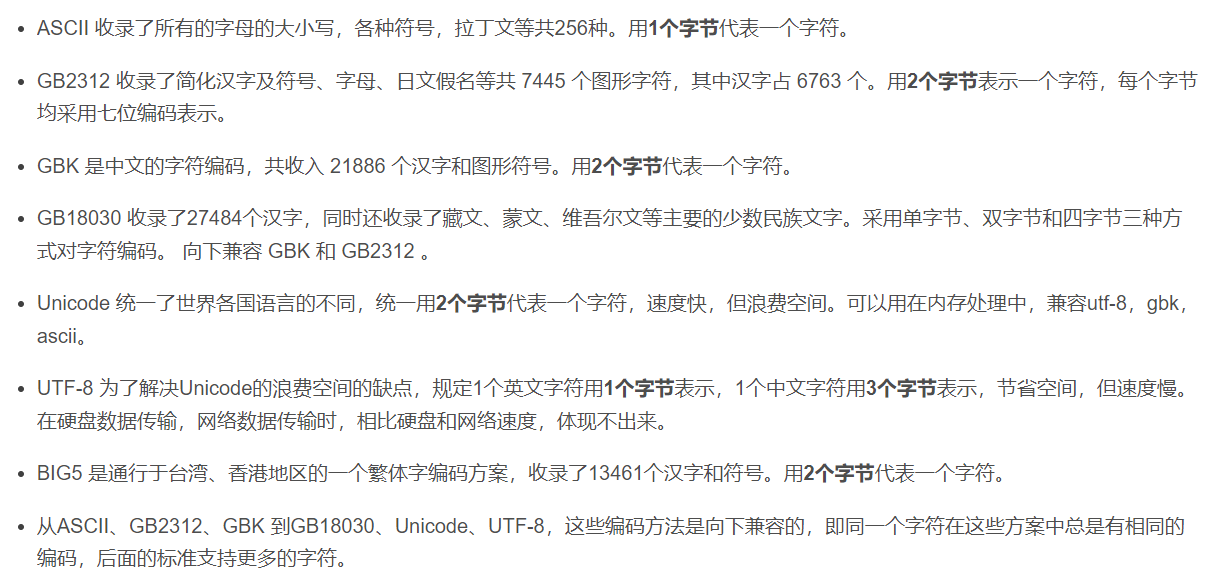

7、skiprows：表示过滤行，想过滤掉哪些行，就写在一个列表里面传递给skiprows即可。注意的是：这里是先过滤，然后再确定表头，比如：

In [18]:
# 读取数据源中students文件，过滤掉索引为0和3的行
pd.read_csv(r"数据源\students.csv",skiprows = [0,3])

,1,朱梦雪,地球村,女,2004/11/2
0,2,许文博,月亮星,女,2003/8/7
1,4,付延旭,克哈星,男,2003/10/11
2,5,王杰,查尔星,男,2002/6/12
3,6,董泽宇,塔桑尼斯,男,2002/2/12


这里把第一行过滤掉了，因为第一行是表头，所以在过滤掉之后第二行就变成表头了。 当然里面除了传入具体的数值，来表明要过滤掉哪些行，还可以传入一个函数。

In [19]:
# 读取数据源中students文件，保留索引为0的行，过滤掉id为偶数的行
pd.read_csv(r"数据源\students.csv",skiprows = lambda x : x > 0 and x % 2 == 0)

,id,name,address,gender,birthday
0,1,朱梦雪,地球村,女,2004/11/2
1,3,张兆媛,艾尔星,女,2004/11/2
2,5,王杰,查尔星,男,2002/6/12


## 2.2 CSV文件的写入

（1）可以用**Series.to_csv()**和**DataFrame.to_csv()**函数实现Series对象和DataFrame对象的CSV写入。该函数提供了20多个参数，可以非常灵活的读取数据。  
（2）Series.to_csv()和DataFrame.to_csv()函数须重点掌握的参数：

| 参数         | 参数作用             | 默认值 | 参数取值或注意事项                       |
| :------------ | :-------------------- | :------ | :---------------------------------------- |
| **filepath** | 指定文件路径         |        | 注意路径字符串的写法，最好用**r**定义。  |
| **encoding** | 指定字符编码方式     | None   | 常用如gbk，gb2312，utf-8，utf-8-sig。    |
| **header**   | 是否写入列名所在行   | True   | 默认要写入列名所在行；False，不写入。    |
| **index**    | 是否写入行索引所在列 | True   | 默认要写入行索引所在列；False，不写入。  |
| **columns**  | 要写入的字段         | None   | 即当前DataFrame中哪些字段需要写入。      |
| **mode**     | 指定写入方式         | 'w'    | 默认覆盖写，'a'表示追加写。              |
| **na_rep**   | 缺失数据填充         | ''     | 将缺失数据填充为其他值，默认为空字符串。 |

【练习1】  
将“数据源\股票相关数据\data\csv格式”中的股票基本信息.csv读取到pandas中，并命名为变量df。  
将df1中的ts_code、name、list_date写入到本地。文件名为df1.csv；路径为：在当前路径中创建一个名为result的文件夹，并将结果写入该文件夹中；不写入索引所在列，写入方式为追加写。

In [20]:
# 读取文件，命名为df
df = pd.read_csv(r'数据源\股票相关数据\data\csv格式\股票基本信息.csv')

In [21]:
# 创建result文件夹
import os
os.mkdir('result')

In [22]:
# 写入ts_code、name、list_date写入到result文件中，写入方式为追加，编码为gb18030，不写入索引所在列
df.to_csv(r'result\df1.csv',columns = ['ts_code','name','list_date'],mode = 'a',encoding = 'gb18030',index = False)

# 3. Excel文件的读写

## 3.1 Excel文件的读取

（1）Excel文件的读取采用**pd.read_excel()**函数，该函数提供了20多个参数，可以非常灵活的读取数据。  
（2）pd.read_excel()函数须重点掌握的参数：

|           参数 | 参数作用         | 默认值 | 参数取值或注意事项                                           |
| :------------- | :--------------- | :------ | :------------------------------------------------------------ |
|         **io** | 指定文件路径     |        | 注意路径字符串的写法，最好用**r**定义。                      |
| **sheet_name** | 指定sheet        | 0      | 默认读取索引为0的sheet中的数据；该参数也可以是sheet的字符串名字。 |
|     **header** | 指定表头所在行   | 0      | 默认以索引为0的行作为表头（列名）；取None表示没有表头（即表格中都是数据）；取1表示以索引为1的行作为表头。 |
|  **index_col** | 指定行索引所在列 | None   | 默认自动生成0开始的位置索引；取0表示以索引为0的列作为行索引所在列。此外，参数取值可以是位置索引，也可以是名称索引，且可以是组合索引，如index_col = [1,2,3]。 |
|    **usecols** | 指定要读取的列   | None   | 当不需要读取全部列时，可以使用此参数读取指定列。如usecols=[0,2,8] |

【练习】将“数据源”文件夹中的表2《Python语言程序设计》课程成绩.xlsx文件中的2班成绩读入到pandas中，命名为df,并以学号作为索引。

In [23]:
df = pd. read_excel(r'数据源\表2《Python语言程序设计》课程成绩.xlsx',
sheet_name= 1,
header= 1,
index_col= 1)
df. head(2)

,序号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩,备注
学号,,,,,,,,,,,,,,
60060250201,1,夏镭,100.0,80.0,100.0,36.0,25.0,0.0,52.0,100.0,47.0,57.0,61.15,NaN
60060250202,2,陶磊,100.0,90.0,100.0,75.0,48.0,90.0,91.0,100.0,52.0,67.0,76.20,NaN


【练习】将“数据源”文件夹中的表2《Python语言程序设计》课程成绩.xlsx文件中的1班籍贯读入到pandas中，并以姓名作为索引，命名为df1。

In [24]:
df1 = pd. read_excel(r'数据源\表2《Python语言程序设计》课程成绩.xlsx',
sheet_name= 2,
header= 0,
index_col= 2)
df1. head(2)

,序号,学号,籍贯
姓名,,,
任红,1,60060250101,四川
李思梦,2,60060250102,四川


## 3.2 ExcelFile类

pandas提供了一个ExcelFile类，ExcelFile类有一个属性：**sheet_names**，该属性返回整个Excel工作簿中所有的sheet名字。然后，就可以通过df1.append(df2)  #上下拼接；pd.concat([df1, df2])  #上下拼接；pd.concat([df1, df2], axis=1)  #左右拼接；pd.merge(df1, df2)  #左右关联等方法实现表的连接。

In [25]:
df = pd. ExcelFile(r'数据源\表2《Python语言程序设计》课程成绩.xlsx')
df. sheet_names

['1班成绩', '2班成绩', '1班籍贯']

【练习】读取“数据源”文件夹中的表2《Python语言程序设计》课程成绩.xlsx文件中1班成绩和2班成绩，并将成绩合并在一个DataFrame对象中，将该DataFrame对象命名为df2。

方法1

In [27]:
# 1班成绩命名为df_1
df_1 = pd. read_excel(r'数据源\表2《Python语言程序设计》课程成绩.xlsx',
sheet_name= 0,
header = 1)
df_1.head(2)

,序号,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩,备注
0,1,60060250101,任红,100.0,80.0,100.0,36.0,25.0,0.0,52.0,100.0,47.0,57.0,61.15,NaN
1,2,60060250102,李思梦,100.0,90.0,100.0,75.0,48.0,90.0,91.0,100.0,52.0,67.0,76.20,NaN


In [28]:
# 2班成绩命名为df_2
df_2 = pd. read_excel(r'数据源\表2《Python语言程序设计》课程成绩.xlsx',
sheet_name= 1,
header= 1)
df_2. head(2)

,序号,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩,备注
0,1,60060250201,夏镭,100.0,80.0,100.0,36.0,25.0,0.0,52.0,100.0,47.0,57.0,61.15,NaN
1,2,60060250202,陶磊,100.0,90.0,100.0,75.0,48.0,90.0,91.0,100.0,52.0,67.0,76.20,NaN


In [30]:
# 合并数据df2
df2 = pd. concat([df_1,df_2],ignore_index= True)
df2

,序号,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩,备注
0,1,60060250101,任红,100.0,80.0,100.0,36.0,25.0,0.0,52.0,100.0,47.0,57.0,61.15,NaN
1,2,60060250102,李思梦,100.0,90.0,100.0,75.0,48.0,90.0,91.0,100.0,52.0,67.0,76.20,NaN
2,3,60060250103,王伟杰,100.0,70.0,100.0,74.0,35.0,87.0,86.0,100.0,54.0,79.0,78.10,NaN
3,4,60060250104,肖鹏,100.0,100.0,100.0,85.0,60.0,77.0,72.0,100.0,69.0,71.0,80.00,NaN
4,5,60060250105,朱柯宁,100.0,90.0,100.0,71.0,30.0,97.0,91.0,100.0,84.0,76.0,82.25,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,36,60060250236,李鑫,0.0,70.0,50.0,60.0,40.0,0.0,0.0,0.0,97.0,NaN,NaN,取消期末考试资格
81,37,60060250237,丁超,100.0,100.0,100.0,86.0,35.0,100.0,94.0,100.0,64.0,71.0,80.55,NaN
82,38,60060250238,刘双华,100.0,100.0,100.0,75.0,71.0,80.0,87.0,100.0,74.0,83.0,86.25,NaN
83,39,60060250239,黄萍,100.0,100.0,100.0,67.0,50.0,87.0,91.0,100.0,60.0,47.0,69.55,NaN


方法2

In [31]:
# 读取所有工作表
sheets = pd. ExcelFile(r'数据源\表2《Python语言程序设计》课程成绩.xlsx')
sheets

In [32]:
# 1班成绩命名为df_1
df_1 = pd. read_excel(sheets,sheet_name= '1班成绩',header= 1)
df_1. head(2)

,序号,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩,备注
0,1,60060250101,任红,100.0,80.0,100.0,36.0,25.0,0.0,52.0,100.0,47.0,57.0,61.15,NaN
1,2,60060250102,李思梦,100.0,90.0,100.0,75.0,48.0,90.0,91.0,100.0,52.0,67.0,76.20,NaN


In [33]:
# 2班成绩命名为df_2
df_2 = pd. read_excel(sheets,sheet_name= '2班成绩',header= 1)
df_2. head(2)

,序号,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩,备注
0,1,60060250201,夏镭,100.0,80.0,100.0,36.0,25.0,0.0,52.0,100.0,47.0,57.0,61.15,NaN
1,2,60060250202,陶磊,100.0,90.0,100.0,75.0,48.0,90.0,91.0,100.0,52.0,67.0,76.20,NaN


In [35]:
# 合并数据df2
df2 = pd. concat([df_1,df_2]). reset_index(drop= True )
df2

,序号,学号,姓名,考勤,课堂表现,作业1,作业2,作业3,作业4,作业5,作业6,半期考试,期末考试,总成绩,备注
0,1,60060250101,任红,100.0,80.0,100.0,36.0,25.0,0.0,52.0,100.0,47.0,57.0,61.15,NaN
1,2,60060250102,李思梦,100.0,90.0,100.0,75.0,48.0,90.0,91.0,100.0,52.0,67.0,76.20,NaN
2,3,60060250103,王伟杰,100.0,70.0,100.0,74.0,35.0,87.0,86.0,100.0,54.0,79.0,78.10,NaN
3,4,60060250104,肖鹏,100.0,100.0,100.0,85.0,60.0,77.0,72.0,100.0,69.0,71.0,80.00,NaN
4,5,60060250105,朱柯宁,100.0,90.0,100.0,71.0,30.0,97.0,91.0,100.0,84.0,76.0,82.25,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,36,60060250236,李鑫,0.0,70.0,50.0,60.0,40.0,0.0,0.0,0.0,97.0,NaN,NaN,取消期末考试资格
81,37,60060250237,丁超,100.0,100.0,100.0,86.0,35.0,100.0,94.0,100.0,64.0,71.0,80.55,NaN
82,38,60060250238,刘双华,100.0,100.0,100.0,75.0,71.0,80.0,87.0,100.0,74.0,83.0,86.25,NaN
83,39,60060250239,黄萍,100.0,100.0,100.0,67.0,50.0,87.0,91.0,100.0,60.0,47.0,69.55,NaN


## 3.3 Excel文件的写入

有两种方法可以进行写入，可以使用to_excel方法或ExcelWriter()类。  
Series.to_excel()和DataFrame.to_excel()函数常用参数如下：

| 参数             | 参数作用             | 默认值 | 参数取值或注意事项                                  |
| :---------------- | :-------------------- | :------ | :--------------------------------------------------- |
| **excel_writer** | 指定文件路径         |        | 注意路径字符串的写法，最好用**r**定义。             |
| **sheet_name**   | 指定sheet的名字      | Sheet1 | 默认写入的sheet的名字为Sheet1；可修改为其他字符串。 |
| **encoding**     | 指定字符编码方式     | None   | 常用如gbk，gb2312，utf-8，utf-8-sig。               |
| **header**       | 是否写入列名所在行   | True   | 默认要写入列名所在行；False，不写入。               |
| **index**        | 是否写入行索引所在列 | True   | 默认要写入行索引所在列；False，不写入。             |
| **columns**      | 要写入的字段         | None   | 即当前DataFrame中哪些字段需要写入。                 |
| **na_rep**       | 缺失数据填充         | ''     | 将缺失数据填充为其他值，默认为空字符串。            |
| **startrow**     | 开始写入的行         | 0      | 默认从索引为0的行开始写。                           |
| **startcol**     | 开始写入的列         | 0      | 默认从索引为0的列开始写。                           |

【练习】将df2写入到result文件夹中，文件名为df2.xlsx。

In [37]:
# 将刚刚合并的df2写入result文件中
df2. to_excel(r'result\df2.xlsx',index= False)

## 3.4 Excel追加写ExcelWriter()

（1）在pandas中，通常使用to_excel()方法将DataFrame导出至Excel文件上，如果需要将多个不同的DataFrame导出到同一个Excel文件的不同Sheet页，可以使用pandas.ExcelWriter()类来实现。  
（2）DataFrame.to_excel()没有mode参数，一般只能覆盖写，不能追加写。但是可以通过**ExcelWriter类**，并且结合改变**startrow**的方式实现追加写。

【练习】1.下面代码为在df3.xlsx中写入sheet1，sheet2两个表

In [ ]:
df1 = pd.DataFrame({'名字': ['张三', '王四'], '分数': [100, 100]})
df2 = pd.DataFrame({'年龄': ['18', '19'], '性别': ['男', '女']})
 


【练习】2.新增表单,可以通过在ExcelWriter中添加mode参数，新增一个sheet。该参数默认为w，修改为a的话，可以在已存在sheet的excel中添加sheet表。

In [ ]:
df3 = pd.DataFrame({'新增表': ['1', '2']})


【练习】3.覆盖excel中已有sheet。如果需要重新写入excel中某个sheet，直接往excel写入同名sheet是不可以的，命令会覆盖原本的所有数据，因此需采用以下方法。

In [ ]:
df4 = pd.DataFrame({'test':['2017002038','2017003024']})
      #openpyxl对已有的文件进行追加操作和格式操作
     # openpyxl.workbook.workbook.Workbook 获取所有sheet
     #删除需要覆盖的sheet
     #sheet3的内容更新成df4值

【练习】4.已有sheet中追加数据。实现excel的追加，可以将原有的数据先读出来，然后与需要存入的数据一并添加即可。

In [ ]:
# 待追加的数据
df5 = {'名字': ['李五', '赵六', '孙七'],
         '分数': [90,60,68]}
df5 = pd.DataFrame(df5)

# 读取相应sheet中原本的数据

# 将新数据与旧数据合并起来


# 覆盖掉原有的sheet

     # openpyxl.workbook.workbook.Workbook 获取所有sheet
     #删除需要覆盖的sheet
     #sheet1的内容更新成save_data值

【练习】将“数据源”文件夹中的表2《Python语言程序设计》课程成绩.xlsx文件中的1班成绩读入到pandas中，写入result文件夹中，文件名为df4.xlsx。然后再将2班成绩读入到pandas中，并追加写入到df4.xlsx文件中的1班成绩读入到pandas中，写入result文件夹中，文件名为df4.xlsx中。

In [ ]:
# 1班成绩df_1


In [ ]:
# df_1写入result中命名为df4


In [ ]:
# 2班成绩df_2


In [ ]:
# 合并成绩，命名为df_3


# 将df_2追加写入df4中，将sheet命名为合并

    # openpyxl.workbook.workbook.Workbook 获取所有sheet
     #删除需要覆盖的sheet
     #sheet1的内容更新成save_data值

方法2

# 4.数据库

## 4.1数据库读取

pandas中提供了pd.read_sql()、pd.read_sql_query() 和 pd.read_sql_table()共3个函数读取数据库中的数据，并提供了DataFrame.to_sql()函数将DataFrame对象写入到数据库中。  
pandas对数据库数据的读写均需要先创建与数据库之间的连接。不过通过上面函数主要实现对数据库数据的读写操作，不能进行其他操作，如DDL，或DML（INSERT、DELETE、UPDATE）等。如果想要实现对数据库更加完整的操作，可通过pymysql、pymssql等第三方库实现。

In [ ]:
pip install pandas sqlalchemy pymysql

### 4.1.1数据库连接

In [ ]:


# 数据库连接信息
DB_USER = ''
DB_PASSWORD = ''
DB_HOST = ''  
DB_PORT = ''
DB_NAME = ''

# 创建数据库引擎
engine = create_engine(
    f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

### 4.1.2数据库读取

In [ ]:
# 执行SQL查询，读取一般籍贯，将序号作为索引


In [ ]:
# 读取1班籍贯中籍贯为四川的学生信息，将序号作为索引


## 4.2数据库写入

【练习】读取“数据源”文件夹中的表2《Python语言程序设计》课程成绩.xlsx文件中1班成绩和2班成绩，1班成绩命名为df_1,2班成绩命名为df_2，分别将df_1和df_2写入数据库中，表名称为test

In [ ]:
# 1班成绩，命名为df_1


In [ ]:
# 2班成绩，命名为df_2


In [ ]:
# 将 df_1写入新表,表名为test


In [ ]:
# 将 df_2追加写入test表


## 4.3pyodbc简介

可以通过python连接数据库，对数据库进行DDL、DML等操作。python连接并操作数据库需要引入第三方库，针对不同的数据库软件，有不同的第三方库，如**pymysql、pymssql**等，也有支持连接多种数据库软件的第三方库，如**pyodbc**。需要注意的是：python这些第三方库连接数据库时，可能导致数据库本身操作变慢。

pyodbc是Microsoft推出的，可用于连接多种数据库的python库。官网地址：https://github.com/mkleehammer/pyodbc/wiki  
在针对MySQL连接时，pyodbc和pymysql相比：  
（1）pyodbc适用于多种数据库，pymysql只适用于MySQL。  
（2）pyodbc安装相对麻烦一点，需要多一个步骤，即安装ODBC Driver；pymysql安装简单。  
（3）pyodbc对于中文的支持非常友好。  
（4）在使用方法上，二者总体来说使用方法几乎一致。只是在连接数据库的参数略有差异。

### 4.3.1pyodbc的安装

第一步：pip install pyodbc -i https://pypi.tuna.tsinghua.edu.cn/simple  
第二步：通过执行pyodbc.drivers()函数，查看在返回的列表中，是否有MySQL ODBC XX Unicode Driver。如果有，则不执行此步骤，直接使用pyodbc即可；如果没有，则根据自己电脑上的MySQL版本，在如下地址汇总下载安装，注意选择合适的版本。https://github.com/mkleehammer/pyodbc/wiki/Connecting-to-SQL-Server-from-Windows 

### 4.3.2pyodbc的使用

**（1）连接MySQL：**使用pyodbc.connect()方法创建连接，并获取Connection对象。  
**（2）操作MySQL：**通过Connection对象，创建Cursor对象。然后使用Cursor对象的各种方法与数据库进行DDL、DML等交互操作。   
1）Cursor对象执行包括两类：**Cursor.execute("<SQL代码>")、cursor.executemany("SQL代码",<二维数组>)**。  
2）在创建Connection对象时，可以设置自动提交。如果没有设置自动提交，则所有的创建、新增、删除、更新等操作，在Cursor对象执行之后，可能需要通过Connection对象提交，即**Connection.commit()**。  
3）对于查询操作，不需要进行commit，但是在Cursor对象执行之后，还需要通过**Cursor.fetchone()、Cursor.fetchmany(n)、Cursor.fetchall()**等方法获取查询的结果。  
**（3）关闭MySQL：**依次关闭Cursor对象，关闭Connection对象。

In [ ]:
# 设置数据库连接参数
server = ''
database = ''
username = ''
password = ''
# 创建Connection对象，必须指定合适的ODBC驱动程序，此外，PRINT @@SERVERNAME查看服务名。
con = pyodbc.connect(
    f'DRIVER={{MySQL ODBC 8.0 Unicode Driver}};SERVER={server};DATABASE={database};UID={username};PWD={password}',
    autocommit=True)

In [ ]:
# 创建Cursor对象
cursor = con.cursor()

### 4.3.3操作

DDL语句，如切换数据库、创建表、删除表等也可以执行。不过，DDL最好直接在数据库软件中进行，更加方便。下面重点介绍DML。

#### 4.3.3.1查询

进行查询操作时，必须通过Cursor对象的fetch系列方法来获取结果；此外，须特别注意：**Cursor是动态的**。
+ fetchone()：返回一条记录，如果没有结果则返回None。相当于：cursor.fetchmany(1)。
+ fetchmany(n)：返回前n条记录，如果没有结果则返回None。
+ fetchall()：返回所有记录，如果没有结果则返回None。

In [ ]:
sql = "SELECT * FROM test"
cursor.execute(sql)

In [ ]:
# 查找第一条记录


In [ ]:
# 返回前3条记录


In [ ]:
# 返回所以记录


#### 4.3.3.2新增
创建Cursor对象后，通过execute()或executemany()来执行SQL语句：
+ cursor.execute("SQL语句")：一条一条操作，如一条一条插入数据。
+ cursor.executemany("SQL语句",<二维数组>)：批量插入数据，将一个二维数组插入表中。SQL语句中占位符号为：?。

(1)execute

In [ ]:
# 新增一条记录('200','60060250200', '龚磊', '90.0', '90.0', '90.0', '90.0', '90.0','90.0', '90.0', '90.0', '90.0', '90.0', '90.0','新增')


In [ ]:
cursor.execute("SELECT count(*) FROM test")
cursor.fetchall()

(2)executemany

In [ ]:
# 新增三条记录
# ('201','60060250201', '张三', '90.0', '90.0', '90.0', '90.0', '90.0','90.0', '90.0', '90.0', '90.0', '90.0', '90.0','新增'),
# ('202','60060250202', '李四', '90.0', '90.0', '90.0', '90.0', '90.0','90.0', '90.0', '90.0', '90.0', '90.0', '90.0','新增'),
# ('203','60060250203', '王五', '90.0', '90.0', '90.0', '90.0', '90.0','90.0', '90.0', '90.0', '90.0', '90.0', '90.0','新增')
# 占位符号为：?


In [ ]:
cursor.execute("SELECT count(*) FROM test")
cursor.fetchall()

#### 4.3.3.3删除

In [ ]:
# 删除备注为新增的记录


In [ ]:
cursor.execute("SELECT count(*) FROM test")
cursor.fetchall()

#### 4.3.3.4更新

In [ ]:
# 更新姓名为任红同学的备注信息为“修改”

# 如果连接时，没有指定：autocommit=True，则必须con.commit()手动提交。

### 4.3.4关闭

In [ ]:
# 关闭Cursor对象和Connection对象


# 5. 练习与答案

练习1：读取“表1《Python语言程序设计》课程成绩”中：序号、学号、姓名、总成绩等4列，并以序号为索引，命名为df。读取完成后，将其以CSV格式写入，存放在**result文件夹**下，文件名称为“练习1”，其他保持默认或根据实际需要设置。

In [4]:
df = pd.read_csv(r"数据源/表1《Python语言程序设计》课程成绩.csv",header = 1,usecols = ['序号','学号','姓名','总成绩'],index_col = '序号',encoding = 'gbk')

In [5]:
df.to_csv(r'result\练习1.csv')

练习2：读取“表2《Python语言程序设计》课程成绩”的“1班成绩”表中全部数据,命名为df1。读取完成后，将其以Excel格式写入，空数据（NaN）全部替换成字符串“Null”存放在**代码文件的上一级路径**下，文件名称为“练习2”，其他保持默认或根据实际需要设置。

# 4. 总结

（1）pd.read_csv()、pd.read_excel()  
（2）pd.to_csv()、pd.to_excel()  
（3）pd.ExcelFile、ExcelFile.sheet_names  
（4）pd.read_sql、pd.to_sql()  
（5）pyodbc